Washington DC 2025 Crime Data Analysis
-
-
Problem Space
- 
-
Crime is a massive problem in the US. Washington DC, the capital of the country, has seen progressively more and more crime. Identifying the causes, areas, and methods of these crimes, is the only way to put a stop to them.


In This Project, I am analysing the most common crimes and patterns related to the crimes.

This will help police have a good idea on where to man up and crackdown.

<>
-
-
Dataset Explanation

The dataset I'm using is the DC Metropolitan Police Department crime incidents. 

It shows the offense, the ward the crime was commited in, the block, the time of day, when the crime happened, and how the crime was commited.

In [31]:
import pandas as pd
import numpy as np
import os
os.listdir()


['.git',
 'project2.ipynb',
 'README.md',
 '2022Wards_small.png',
 'Crime_Incidents_-_2025.csv']

In [32]:
df = pd.read_csv("Crime_Incidents_-_2025.csv")

# Preview first rows
df.head()


,X,Y,CCN,REPORT_DAT,START_DATE,END_DATE,BLOCK,OFFENSE,METHOD,SHIFT,...,BLOCK_GROUP,CENSUS_TRACT,VOTING_PRECINCT,BID,XBLOCK,YBLOCK,LATITUDE,LONGITUDE,OBJECTID,OCTO_RECORD_ID
0,399612.050,137531.8000,25005750,2025/01/15 11:14:41+00,2025/01/13 17:08:00+00,2025/01/13 17:29:00+00,100 - 208 BLOCK OF M STREET NE,THEFT F/AUTO,OTHERS,MIDNIGHT,...,010603 3,10603.0,Precinct 144,NOMA,399612.05000,137531.800000,38.905644,-77.004473,852490263,NaN
1,397430.206,137185.7245,25056241,2025/04/18 17:13:15+00,2025/04/18 04:30:00+00,2025/04/18 05:00:00+00,13TH STREET NW AND K STREET NW,MOTOR VEHICLE THEFT,OTHERS,DAY,...,010100 3,10100.0,Precinct 129,DOWNTOWN,397430.20598,137185.724509,38.902522,-77.029626,852490264,NaN
2,394784.250,137339.7300,25061581,2025/04/28 04:43:21+00,2025/04/28 02:06:00+00,2025/04/28 02:40:00+00,1000 - 1099 BLOCK OF THOMAS JEFFERSON STREET NW,THEFT/OTHER,OTHERS,MIDNIGHT,...,000102 3,102.0,Precinct 5,GEORGETOWN,394784.25000,137339.730000,38.903898,-77.060131,852490265,NaN
3,397430.660,136664.3700,25063070,2025/04/30 17:06:36+00,2025/04/24 16:15:00+00,2025/04/24 17:30:00+00,600 - 699 BLOCK OF 13TH STREET NW,THEFT/OTHER,OTHERS,DAY,...,005802 1,5802.0,Precinct 129,DOWNTOWN,397430.66000,136664.370000,38.897826,-77.029619,852490266,NaN
4,402357.640,134072.2300,25173695,2025/11/15 11:53:36+00,2025/11/15 11:18:00+00,NaN,2200 - 2305 BLOCK OF PENNSYLVANIA AVENUE SE,THEFT/OTHER,OTHERS,MIDNIGHT,...,007601 1,7601.0,Precinct 111,NaN,402357.64000,134072.230000,38.874475,-76.972830,852490269,NaN


In [33]:
import pandas as pd

df['REPORT_DAT'] = pd.to_datetime(df['REPORT_DAT'], errors='coerce')
df['START_DATE'] = pd.to_datetime(df['START_DATE'], errors='coerce')
df['END_DATE'] = pd.to_datetime(df['END_DATE'], errors='coerce')


df['year'] = df['REPORT_DAT'].dt.year
df['month'] = df['REPORT_DAT'].dt.month

df = df.dropna(subset=['OFFENSE', 'REPORT_DAT'])

Question 1.

What crime was the most common in 2025?

6330.81s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Note: you may need to restart the kernel to use updated packages.


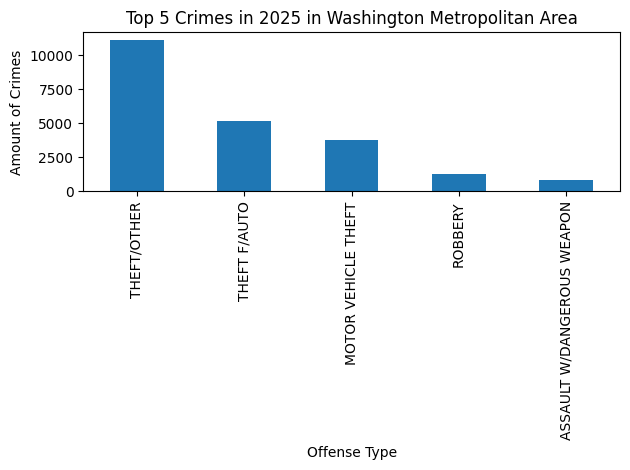

In [34]:
%pip install matplotlib --quiet
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

top3_offenses = df['OFFENSE'].value_counts().nlargest(5)
top3_offenses.plot(kind='bar', title="Top 5 Crimes in 2025 in Washington Metropolitan Area")
plt.xlabel("Offense Type")
plt.ylabel("Amount of Crimes")
plt.tight_layout()
plt.show()

Theft was a common theme amongst the crimes commited. Automabile theft was the second and third highest crime commited in 2025. Assault was much lower as the last.

Question 2.

What Time of Day Had the Most Crime?

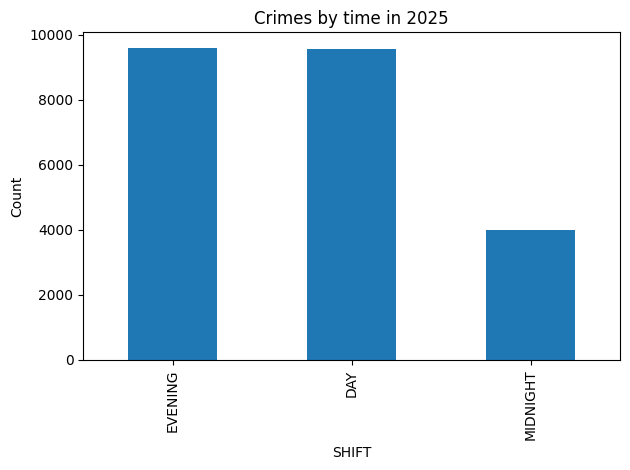

In [35]:
top_shifts = df['SHIFT'].value_counts()
top_shifts.plot(kind='bar', title="Crimes by time in 2025")
plt.xlabel("SHIFT")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Evening and Day were the highest, with midnight being much lower than the 2.

Question 3.

What Month Had The Most Crime?

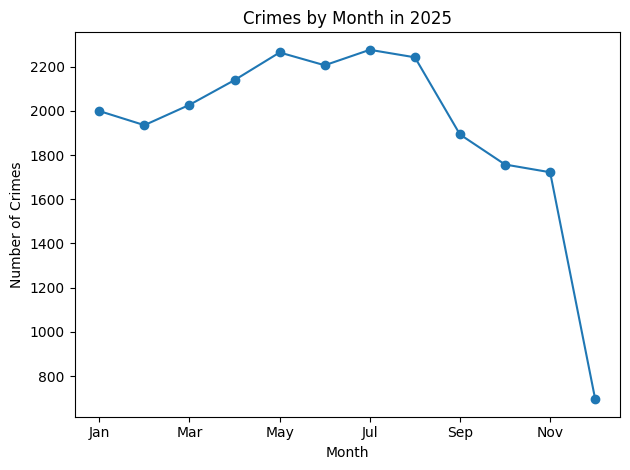

In [36]:
monthly_crimes = df.groupby('month').size()
month_names = {1:"Jan", 2:"Feb", 3:"Mar", 4:"Apr", 5:"May", 6:"Jun",
               7:"Jul", 8:"Aug", 9:"Sep", 10:"Oct", 11:"Nov", 12:"Dec"}
monthly_crimes.index = monthly_crimes.index.map(month_names)

monthly_crimes.plot(kind='line', marker='o', title="Crimes by Month in 2025")
plt.xlabel("Month")
plt.ylabel("Number of Crimes")
plt.tight_layout()
plt.show()

The Summer Months Have The Most Crime Commited, being May to around July. This makes sense as that is around the time DC is busiest. It seems that it doesn't really change all that much through the year though.

Quesiton 4.

What Wards See The Most Crime?

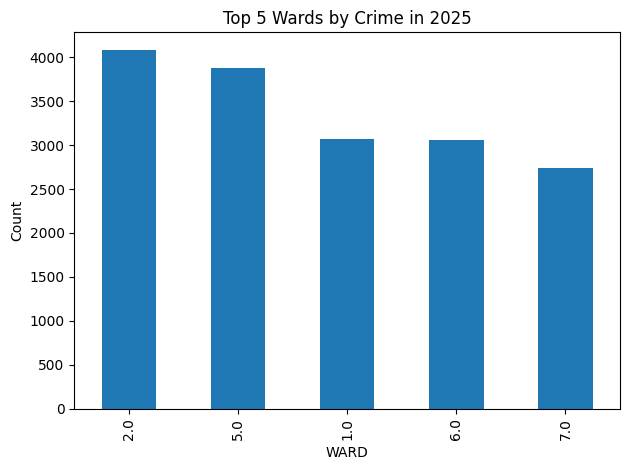

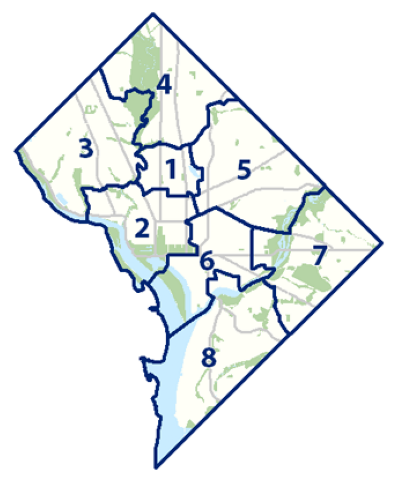

In [37]:
top_wards = df.groupby('WARD')['OFFENSE'].count().nlargest(5)
top_wards.plot(kind='bar', title="Top 5 Wards by Crime in 2025")
plt.xlabel("WARD")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

img = plt.imread("2022Wards_small.png")
plt.figure(figsize=(8,6))
plt.imshow(img)
plt.axis('off')  
plt.show()


^^^^^^ These Are THe Wards In DC

The Data shows that Ward 2 has the most crime commited, which makes sense as it's the busiest part of the district

Question 5.

What Streets/Blocks had the highest number of crime?

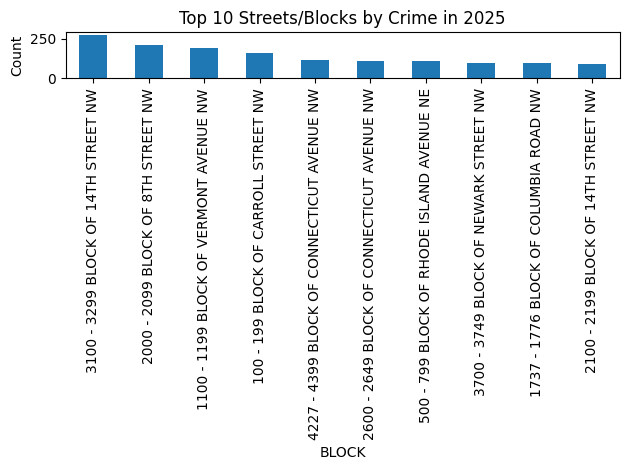

In [38]:
top_blocks = df['BLOCK'].value_counts().nlargest(10)
top_blocks.plot(kind='bar', title="Top 10 Streets/Blocks by Crime in 2025")
plt.xlabel("BLOCK")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


The Block Of 14th Street Has The Highest Number of Crimes In 2025.

Question 6.

What Was the Most Common Method Used to Commit Crime?

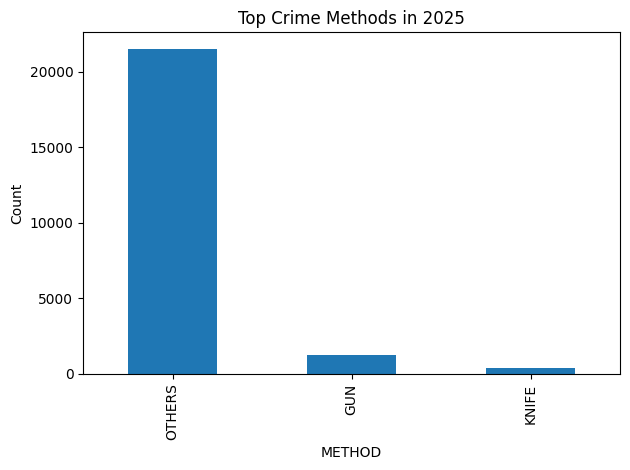

In [39]:
top_methods = df['METHOD'].value_counts().nlargest(5)
top_methods.plot(kind='bar', title="Top Crime Methods in 2025")
plt.xlabel("METHOD")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


"Others" May mean, crimes commited not using violence. It can also be crime commited not using a gun or a knife. That was the most common method. Gun and Knife crime were rather small.

*SUMMARY*

- The Most Crimes Commited were theft and automobile Crimes.

- Evenings and Daytime had the most crimes

- The Summer Months had the highest crime rates

- Ward 2 had the most crimes

- 14th Street had the highest number of crimes

- 'Others' were the most commonly commited method of crimes. knife and gun crimes were second and third but were much lower